In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab

# Fijamos el estilo de la gráfica
sns.set_theme()

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Comparación bootstraps sin estratificar

In [4]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_s_e=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Boostrap por casillas/Distintas_muestras_casillas_bootstrap_sin_est_1.csv", index_col=0)
# Base de bootstrap por votos (submuestreo) método 1
df_boostraps_votos_se=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_sin_est_4_ed_e.csv", index_col=0)

# Renombramos las variables
df_boostraps_votos_se=df_boostraps_votos_se.rename(columns={'Tamaño_submuestra_votos':'Submuestra_votos_o_estratificacion_casillas'})
df_boostraps_c_s_e=df_boostraps_c_s_e.rename(columns={'Estratificación':'Submuestra_votos_o_estratificacion_casillas'})
df_boostraps_votos_se["Submuestra_votos_o_estratificacion_casillas"]=df_boostraps_votos_se["Submuestra_votos_o_estratificacion_casillas"].astype(str)

df_boostraps_votos_se["Submuestra_votos_o_estratificacion_casillas"]=df_boostraps_votos_se["Submuestra_votos_o_estratificacion_casillas"]+' (votos, sin estratificar)'
# Juntamos las bases
df_bootraps_comb_1=pd.concat([df_boostraps_c_s_e,df_boostraps_votos_se]).reset_index(drop=True)
# Guardamos el tamaño de muestra casillas como int
df_bootraps_comb_1["Tamaño_muestra_casillas"]=df_bootraps_comb_1["Tamaño_muestra_casillas"].astype(int)
df_bootraps_comb_1

,Tamaño_muestra_casillas,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE,Submuestra_votos_o_estratificacion_casillas
0,100,0.002082,0.011726,0.032818,JOAQUIN_DIAZ_MENA,0.948,0.043906,0.054279,0.066212,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.730,0.001281,0.003450,0.011382,0.948,0.941,0.917,0.928,0.730,Sin estratificar (casillas)
1,150,0.001481,0.009102,0.027687,JOAQUIN_DIAZ_MENA,0.945,0.037443,0.044915,0.052655,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.809,0.001186,0.003373,0.008262,0.945,0.950,0.936,0.941,0.809,Sin estratificar (casillas)
2,200,0.001470,0.007852,0.022880,JOAQUIN_DIAZ_MENA,0.955,0.034174,0.039497,0.044929,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.826,0.001083,0.002989,0.006531,0.955,0.961,0.946,0.941,0.826,Sin estratificar (casillas)
3,250,0.001444,0.006472,0.020072,JOAQUIN_DIAZ_MENA,0.963,0.031203,0.035486,0.040258,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.864,0.001044,0.002901,0.005749,0.963,0.956,0.946,0.941,0.864,Sin estratificar (casillas)
4,300,0.001181,0.005938,0.018555,JOAQUIN_DIAZ_MENA,0.963,0.029041,0.032597,0.036722,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.880,0.000993,0.002691,0.005168,0.963,0.966,0.952,0.937,0.880,Sin estratificar (casillas)
5,350,0.001161,0.005860,0.016537,JOAQUIN_DIAZ_MENA,0.964,0.027405,0.030672,0.033889,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.909,0.001028,0.002552,0.004640,0.964,0.971,0.943,0.954,0.909,Sin estratificar (casillas)
6,400,0.001071,0.005357,0.016599,JOAQUIN_DIAZ_MENA,0.964,0.025817,0.028835,0.031960,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.929,0.001045,0.002429,0.004210,0.964,0.962,0.960,0.951,0.929,Sin estratificar (casillas)
7,100,0.002026,0.010596,0.032842,JOAQUIN_DIAZ_MENA,1.000,0.115445,0.122616,0.129936,JOAQUIN_DIAZ_MENA,1.000,0.115445,0.122616,0.129936,1.000,1.000,1.000,1.000,1.000,"500 (votos, sin estratificar)"
8,100,0.002171,0.010937,0.033091,JOAQUIN_DIAZ_MENA,0.997,0.081793,0.086440,0.092104,RENAN_BARRERA_CONCHA,0.995,0.080660,0.085519,0.091119,0.997,0.995,1.000,1.000,1.000,"1000 (votos, sin estratificar)"
9,100,0.001964,0.011623,0.030306,JOAQUIN_DIAZ_MENA,0.980,0.057459,0.060825,0.064419,RENAN_BARRERA_CONCHA,0.976,0.056588,0.060032,0.063819,0.980,0.976,0.996,1.000,0.998,"2000 (votos, sin estratificar)"


<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/var/folders/jr/f7xjgzh56h75snyd84nvhbdc0000gn/T/ipykernel_1659/2095318064.py:10: SyntaxWarning: invalid escape sequence '\e'
  per_e.figure.suptitle('Errores máximos ($\epsilon$) comparados (ambos bootstraps)');


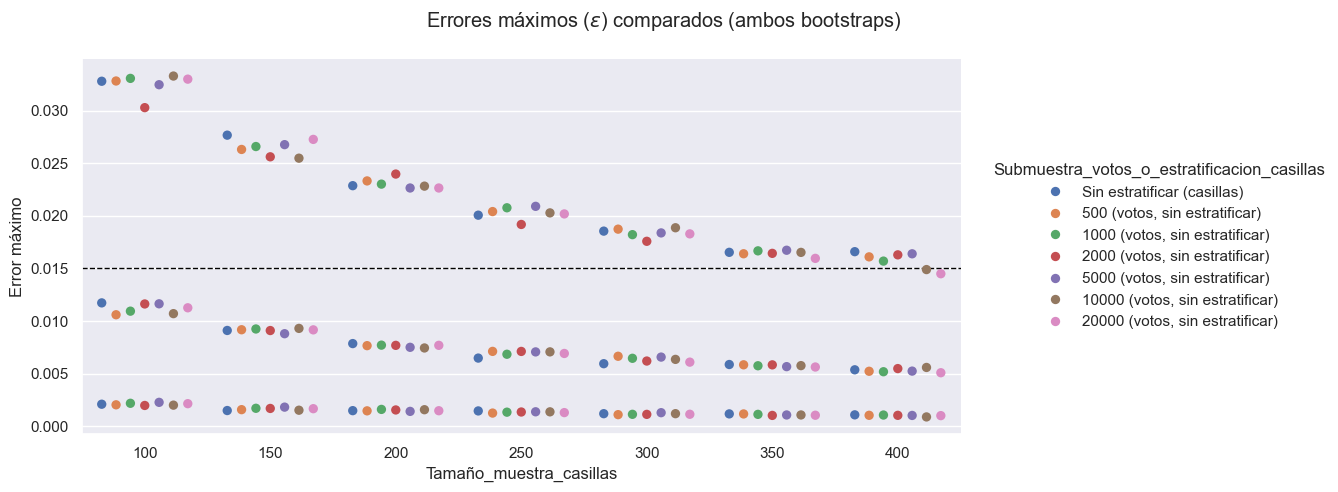

In [5]:
# Para hacer la gráfica del error con los distintos tamaños de la submuestra de votos
df_grafica_error_aux_comb_1=pd.melt(df_bootraps_comb_1[["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas", "Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"]],id_vars=["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas"], value_vars=["Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"])


# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_e=sns.catplot(data=df_grafica_error_aux_comb_1, x="Tamaño_muestra_casillas", y="value", hue="Submuestra_votos_o_estratificacion_casillas", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);
per_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Error máximo')
per_e.figure.subplots_adjust(top=0.9)
per_e.figure.suptitle('Errores máximos ($\epsilon$) comparados (ambos bootstraps)');
per_e.refline(y=0.015, linewidth=1, color='black', ls='--');

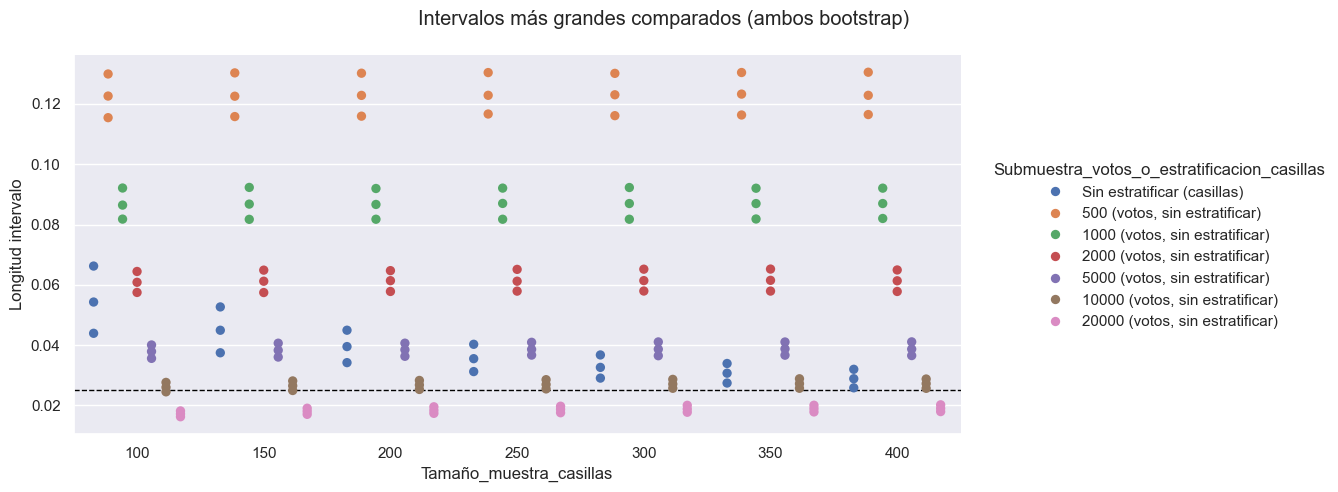

In [6]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_im_aux_comb_1=pd.melt(df_bootraps_comb_1[["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas", "Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas"], value_vars=["Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_i_e=sns.catplot(data=df_grafica_int_im_aux_comb_1, x="Tamaño_muestra_casillas", y="value", hue="Submuestra_votos_o_estratificacion_casillas", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);

per_i_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_i_e.figure.subplots_adjust(top=0.9)
per_i_e.figure.suptitle('Intervalos más grandes comparados (ambos bootstrap)');
per_i_e.refline(y=0.025, linewidth=1, color='black', ls='--');

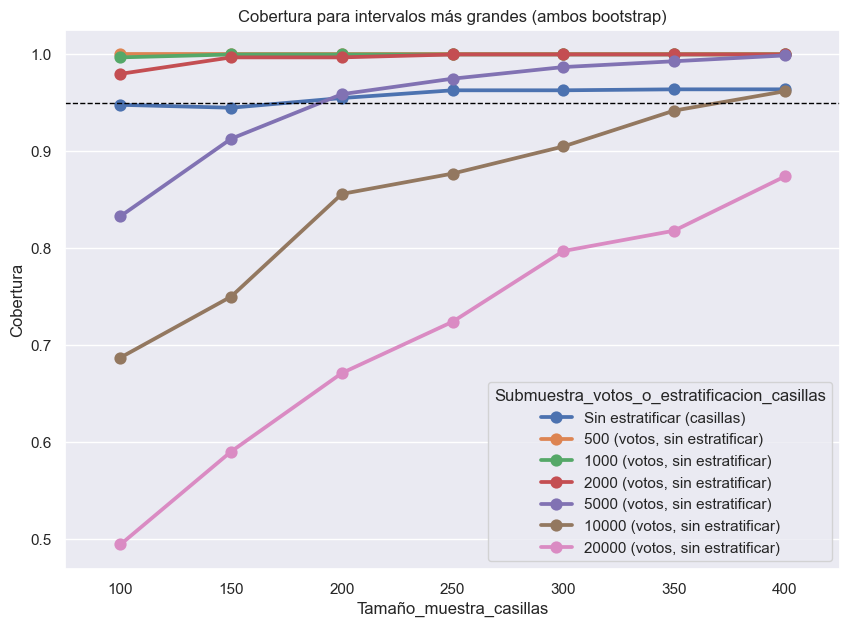

In [7]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,
    data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Intervalo_M_grande_candidato_cob", hue="Submuestra_votos_o_estratificacion_casillas"
).set_title("Cobertura para intervalos más grandes (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

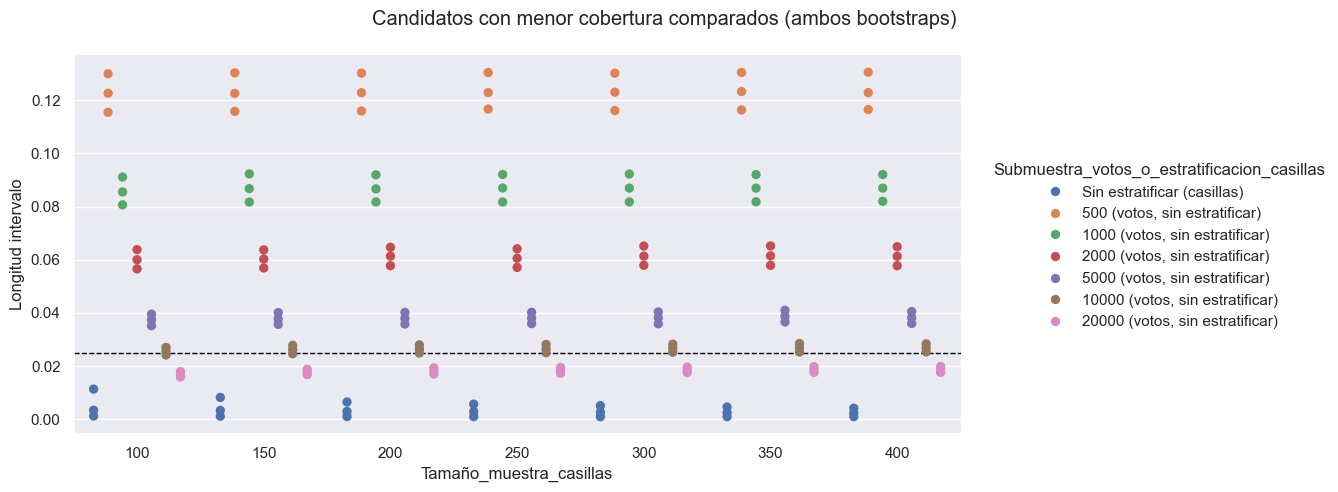

In [8]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_mc_aux_comb_1=pd.melt(df_bootraps_comb_1[["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas", "Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas"], value_vars=["Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_mc_e=sns.catplot(data=df_grafica_int_mc_aux_comb_1, x="Tamaño_muestra_casillas", y="value", hue="Submuestra_votos_o_estratificacion_casillas", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);

per_mc_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_mc_e.figure.subplots_adjust(top=0.9)
per_mc_e.figure.suptitle('Candidatos con menor cobertura comparados (ambos bootstraps)');
per_mc_e.refline(y=0.025, linewidth=1, color='black', ls='--');

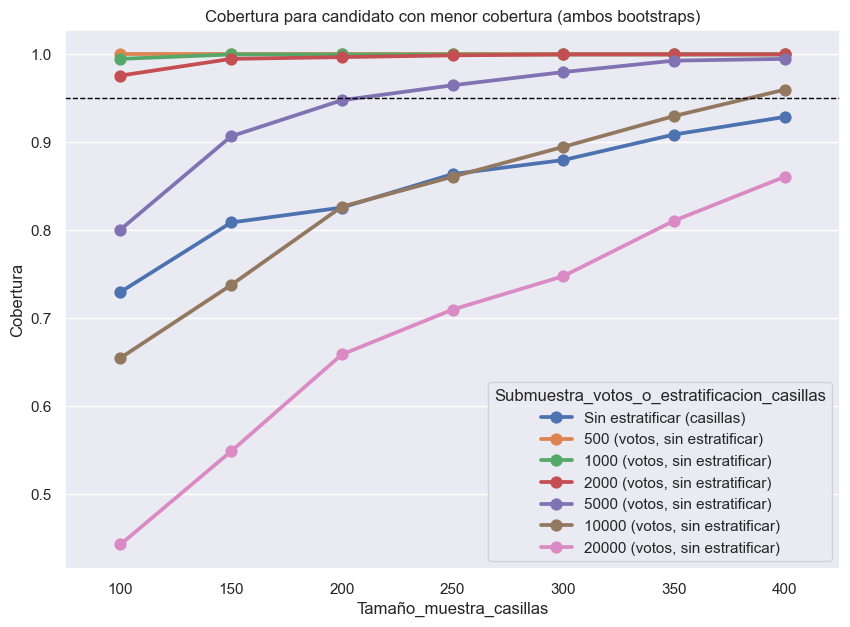

In [9]:
fig, ax = plt.subplots(figsize=(10,7))
sns.pointplot(ax=ax, data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Cobertura_m_candidato", 
              hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura para candidato con menor cobertura (ambos bootstraps)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

### Gráficas de las coberturas por candidato

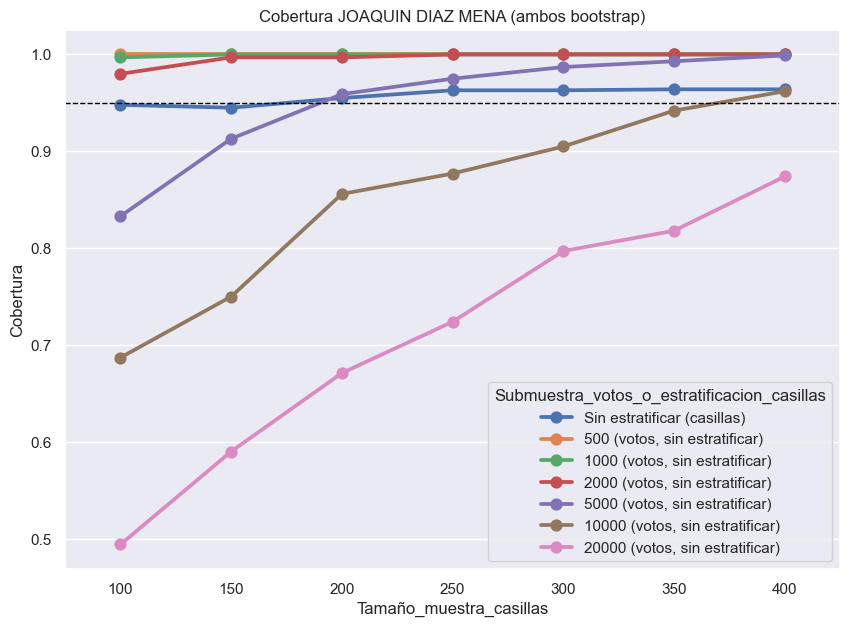

In [10]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Cob_JOAQUIN_DIAZ_MENA", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura JOAQUIN DIAZ MENA (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

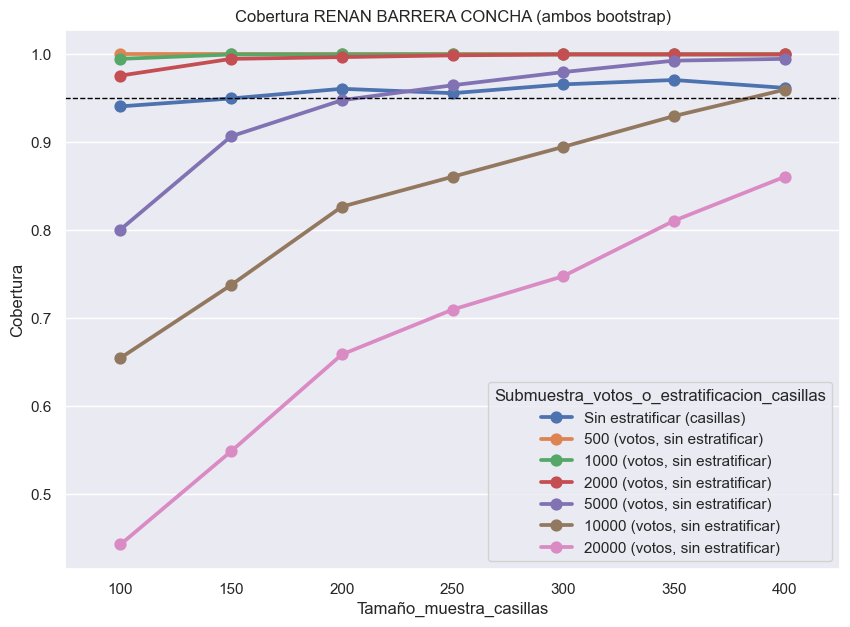

In [11]:
fig, ax = plt.subplots(figsize=(10,7))
sns.pointplot(ax=ax,data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Cob_RENAN_BARRERA_CONCHA", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura RENAN BARRERA CONCHA (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

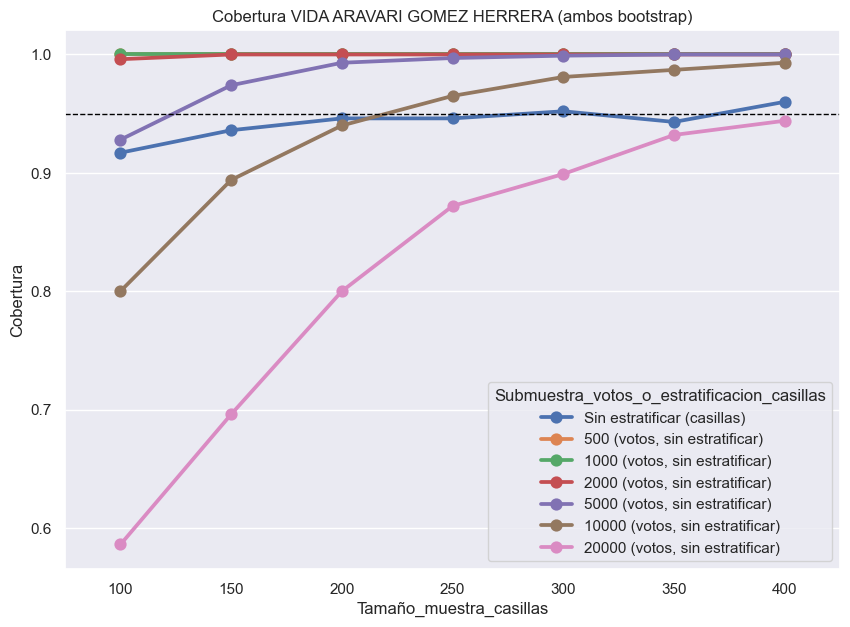

In [12]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Cob_VIDA_ARAVARI_GOMEZ_HERRERA", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura VIDA ARAVARI GOMEZ HERRERA (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

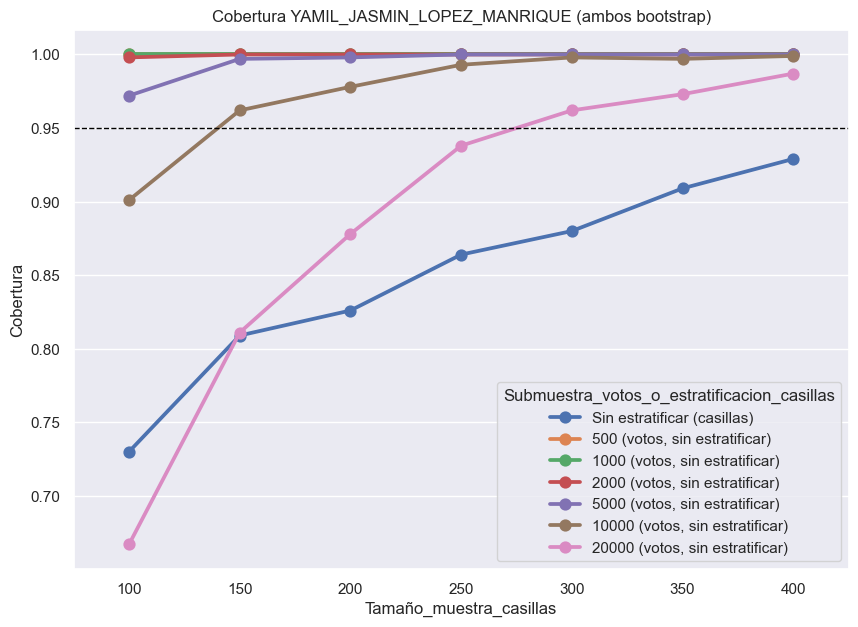

In [13]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura YAMIL_JASMIN_LOPEZ_MANRIQUE (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

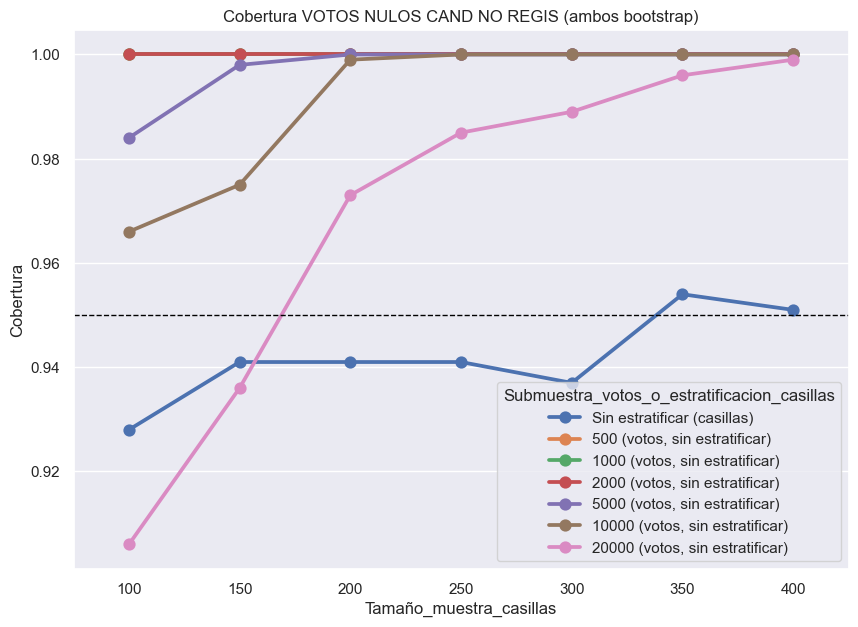

In [14]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_1, x="Tamaño_muestra_casillas", y="Cob_VOTOS_NULOS_CAND_NO_REGIS", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura VOTOS NULOS CAND NO REGIS (ambos bootstrap)");
ax.set(ylabel='Cobertura');
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');

In [15]:
# Leemos las bases
# Base de bootstrap por casillas sin estratificar
df_boostraps_c_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Boostrap por casillas/Distintas_muestras_casillas_bootstrap_estratificado_1.csv", index_col=0)
# Base de bootstrap por votos (submuestreo) método 1
df_boostraps_votos_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_estratificado_2_ed_e.csv", index_col=0)

# Renombramos las variables
df_boostraps_votos_est=df_boostraps_votos_est.rename(columns={'Tamaño_submuestra_votos':'Submuestra_votos_o_estratificacion_casillas'})
df_boostraps_c_est=df_boostraps_c_est.rename(columns={'Estratificación':'Submuestra_votos_o_estratificacion_casillas'})
df_boostraps_votos_est["Submuestra_votos_o_estratificacion_casillas"]=df_boostraps_votos_est["Submuestra_votos_o_estratificacion_casillas"].astype(str)

df_boostraps_votos_est["Submuestra_votos_o_estratificacion_casillas"]=df_boostraps_votos_est["Submuestra_votos_o_estratificacion_casillas"]+' (votos, estratificados por distrito)'
# Juntamos las bases
df_bootraps_comb_2=pd.concat([df_boostraps_c_est,df_boostraps_votos_est]).reset_index(drop=True)
# Guardamos el tamaño de muestra casillas como int
df_bootraps_comb_2["Tamaño_muestra_casillas"]=df_bootraps_comb_2["Tamaño_muestra_casillas"].astype(int)
df_bootraps_comb_2

,Tamaño_muestra_casillas,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE,Submuestra_votos_o_estratificacion_casillas
0,100,0.001909,0.008420,0.024146,JOAQUIN_DIAZ_MENA,0.872,0.025369,0.030919,0.036931,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.680,0.001046,0.002652,0.009110,0.872,0.868,0.847,0.870,0.680,Estratificación por distritos (casillas)
1,150,0.001521,0.007042,0.019725,JOAQUIN_DIAZ_MENA,0.919,0.023360,0.027289,0.031747,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.771,0.000997,0.002603,0.007019,0.919,0.900,0.870,0.907,0.771,Estratificación por distritos (casillas)
2,200,0.001215,0.005826,0.016717,JOAQUIN_DIAZ_MENA,0.931,0.021536,0.024856,0.028727,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.804,0.000941,0.002465,0.005696,0.931,0.919,0.897,0.933,0.804,Estratificación por distritos (casillas)
3,250,0.001011,0.005408,0.014872,JOAQUIN_DIAZ_MENA,0.928,0.020119,0.022862,0.025752,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.866,0.000947,0.002429,0.004988,0.928,0.920,0.919,0.931,0.866,Estratificación por distritos (casillas)
4,300,0.000930,0.004685,0.012806,JOAQUIN_DIAZ_MENA,0.959,0.019086,0.021477,0.024154,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.885,0.000920,0.002311,0.004472,0.959,0.944,0.930,0.935,0.885,Estratificación por distritos (casillas)
5,350,0.000902,0.004381,0.011695,JOAQUIN_DIAZ_MENA,0.964,0.017997,0.020195,0.022511,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.887,0.000906,0.002236,0.003962,0.964,0.956,0.936,0.938,0.887,Estratificación por distritos (casillas)
6,400,0.000882,0.004242,0.011940,JOAQUIN_DIAZ_MENA,0.954,0.017338,0.019241,0.021361,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.908,0.000883,0.002081,0.003616,0.954,0.952,0.941,0.951,0.908,Estratificación por distritos (casillas)
7,100,0.001873,0.008922,0.025022,JOAQUIN_DIAZ_MENA,1.000,0.110900,0.117616,0.124575,JOAQUIN_DIAZ_MENA,1.000,0.110900,0.117616,0.124575,1.000,1.000,1.000,1.000,1.000,"500 (votos, estratificados por distrito)"
8,100,0.002043,0.008720,0.024598,JOAQUIN_DIAZ_MENA,1.000,0.078765,0.083853,0.089344,JOAQUIN_DIAZ_MENA,1.000,0.078765,0.083853,0.089344,1.000,1.000,1.000,1.000,1.000,"1000 (votos, estratificados por distrito)"
9,100,0.001739,0.008590,0.023604,JOAQUIN_DIAZ_MENA,0.998,0.056004,0.059306,0.063054,RENAN_BARRERA_CONCHA,0.995,0.055087,0.058553,0.062510,0.998,0.995,1.000,1.000,0.998,"2000 (votos, estratificados por distrito)"


<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/var/folders/jr/f7xjgzh56h75snyd84nvhbdc0000gn/T/ipykernel_1659/3377988716.py:9: SyntaxWarning: invalid escape sequence '\e'
  per_e.figure.suptitle('Errores máximos ($\epsilon$) comparados (ambos bootstraps)');


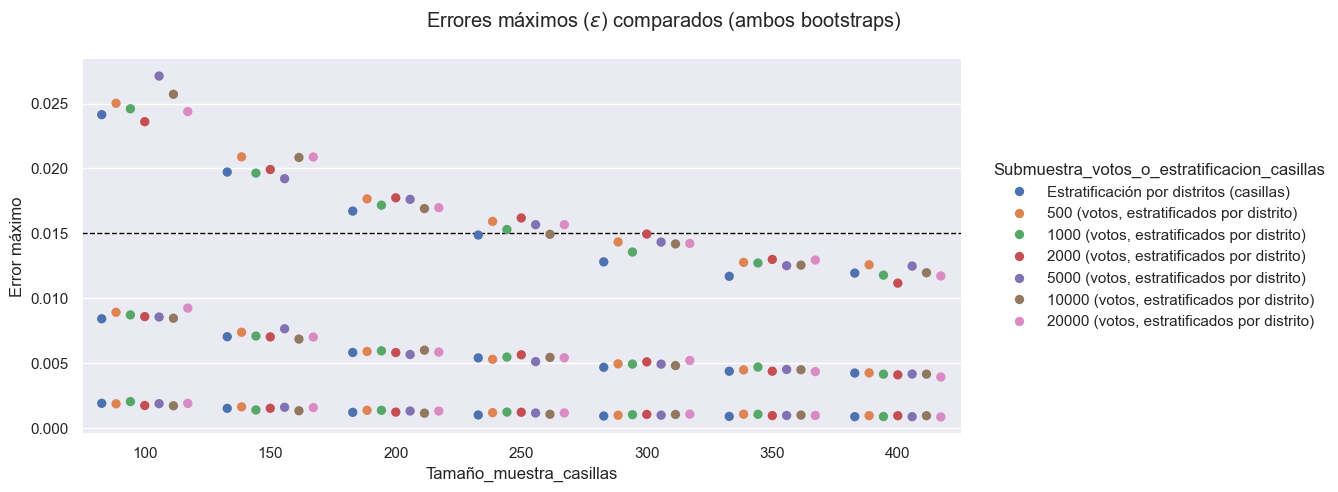

In [16]:
# Para hacer la gráfica del error con los distintos tamaños de la submuestra de votos
df_grafica_error_aux_comb_2=pd.melt(df_bootraps_comb_2[["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas", "Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"]],id_vars=["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas"], value_vars=["Error_maximo_q_025", "Error_maximo_mediana", "Error_maximo_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_e=sns.catplot(data=df_grafica_error_aux_comb_2, x="Tamaño_muestra_casillas", y="value", hue="Submuestra_votos_o_estratificacion_casillas", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);
per_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Error máximo')
per_e.figure.subplots_adjust(top=0.9)
per_e.figure.suptitle('Errores máximos ($\epsilon$) comparados (ambos bootstraps)');
per_e.refline(y=0.015, linewidth=1, color='black', ls='--');

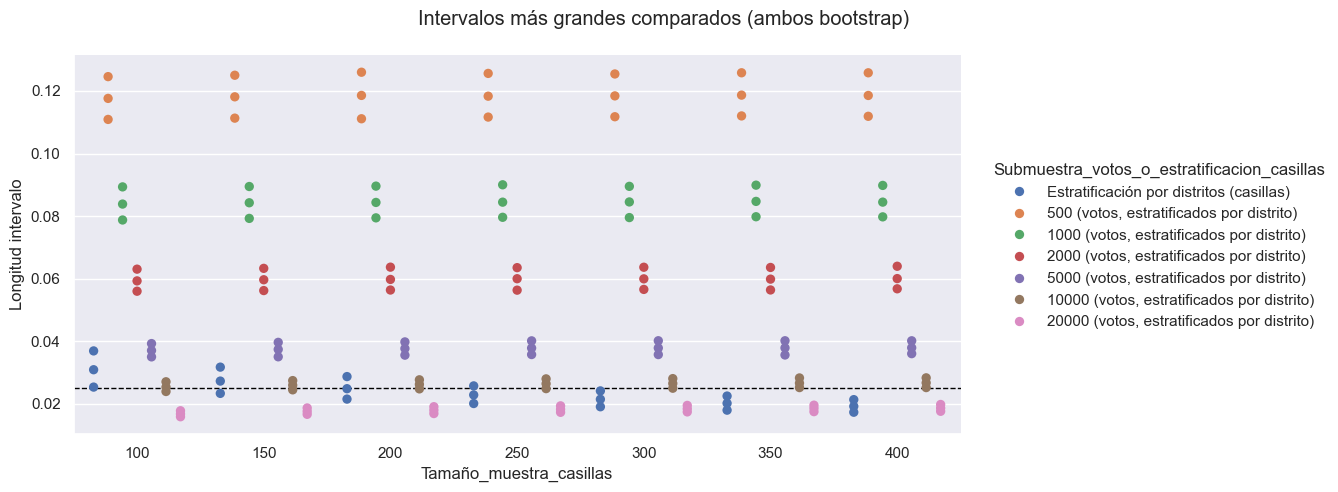

In [17]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_im_aux_comb_2=pd.melt(df_bootraps_comb_2[["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas", "Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas"], value_vars=["Intervalo_M_grande_inter_q_025", "Intervalo_M_grande_inter_mediana", "Intervalo_M_grande_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_i_e=sns.catplot(data=df_grafica_int_im_aux_comb_2, x="Tamaño_muestra_casillas", y="value", hue="Submuestra_votos_o_estratificacion_casillas", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);

per_i_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_i_e.figure.subplots_adjust(top=0.9)
per_i_e.figure.suptitle('Intervalos más grandes comparados (ambos bootstrap)');
per_i_e.refline(y=0.025, linewidth=1, color='black', ls='--');

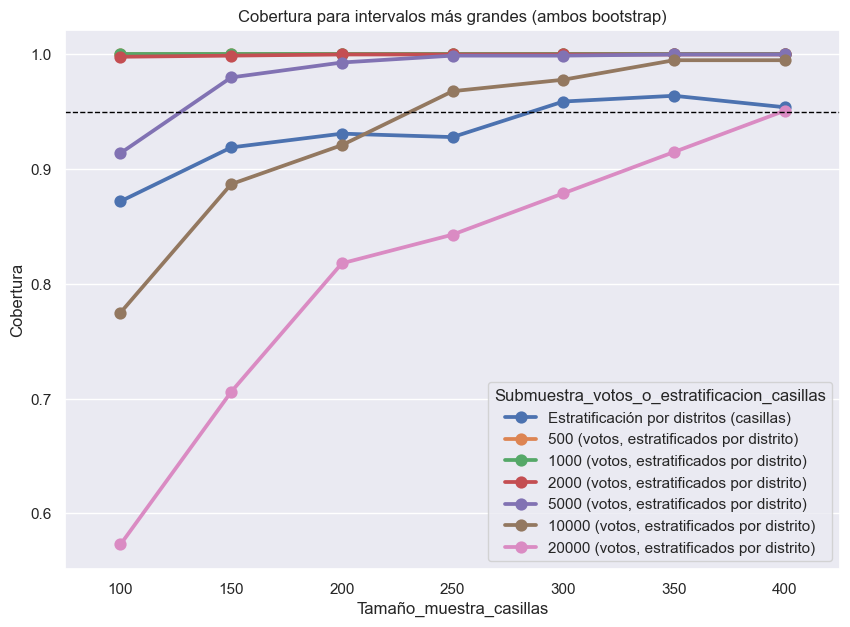

In [18]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,
    data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Intervalo_M_grande_candidato_cob", hue="Submuestra_votos_o_estratificacion_casillas"
).set_title("Cobertura para intervalos más grandes (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

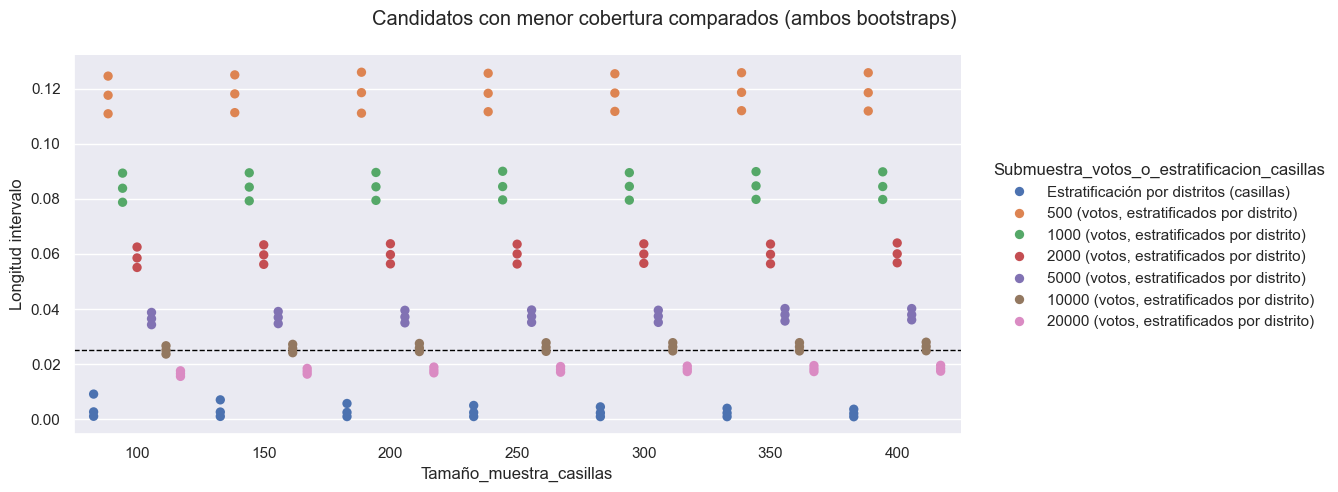

In [19]:
# Para hacer la gráfica de longitud de intervalo (para el candidato con los intervalos más grandes) con los distintos tamños de la submuestra de votos
df_grafica_int_mc_aux_comb_2=pd.melt(df_bootraps_comb_2[["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas", "Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"]],id_vars=["Tamaño_muestra_casillas", "Submuestra_votos_o_estratificacion_casillas"], value_vars=["Cobertura_m_inter_q_025", "Cobertura_m_inter_mediana", "Cobertura_m_inter_q_975"])

# Los tres puntos para cada categoría son los cuantiles 0.025, 0.5 (mediana) y 0.975 (esta fue la mejor forma de identificar hacer la gráfica)

per_mc_e=sns.catplot(data=df_grafica_int_mc_aux_comb_2, x="Tamaño_muestra_casillas", y="value", hue="Submuestra_votos_o_estratificacion_casillas", kind='strip', aspect=2/1, palette="deep", jitter=False, dodge=True, s = 45);

per_mc_e.set(xlabel='Tamaño_muestra_casillas', ylabel='Longitud intervalo')
per_mc_e.figure.subplots_adjust(top=0.9)
per_mc_e.figure.suptitle('Candidatos con menor cobertura comparados (ambos bootstraps)');
per_mc_e.refline(y=0.025, linewidth=1, color='black', ls='--');

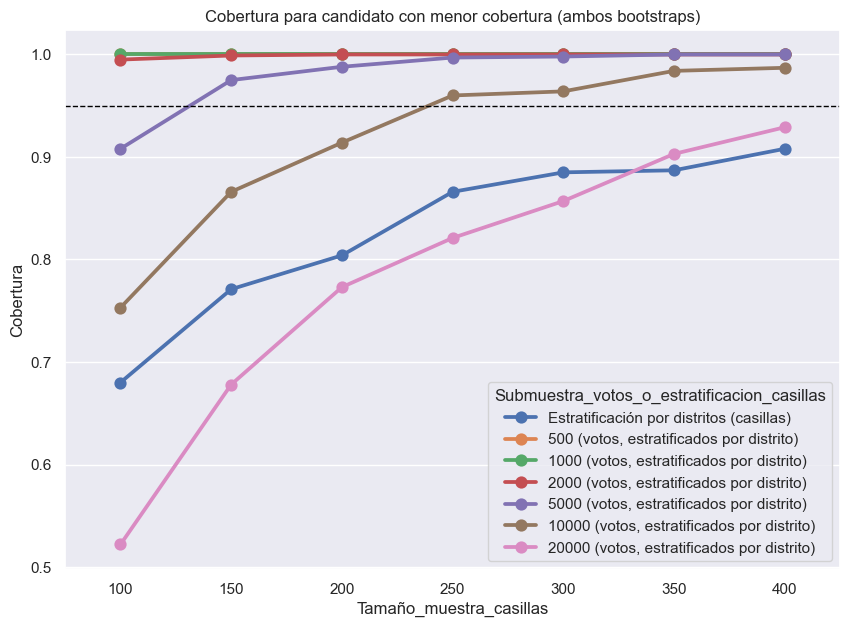

In [20]:
fig, ax = plt.subplots(figsize=(10,7))
sns.pointplot(ax=ax, data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Cobertura_m_candidato", 
              hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura para candidato con menor cobertura (ambos bootstraps)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--');
ax.set(ylabel='Cobertura');

### Gráficas de las coberturas por candidato

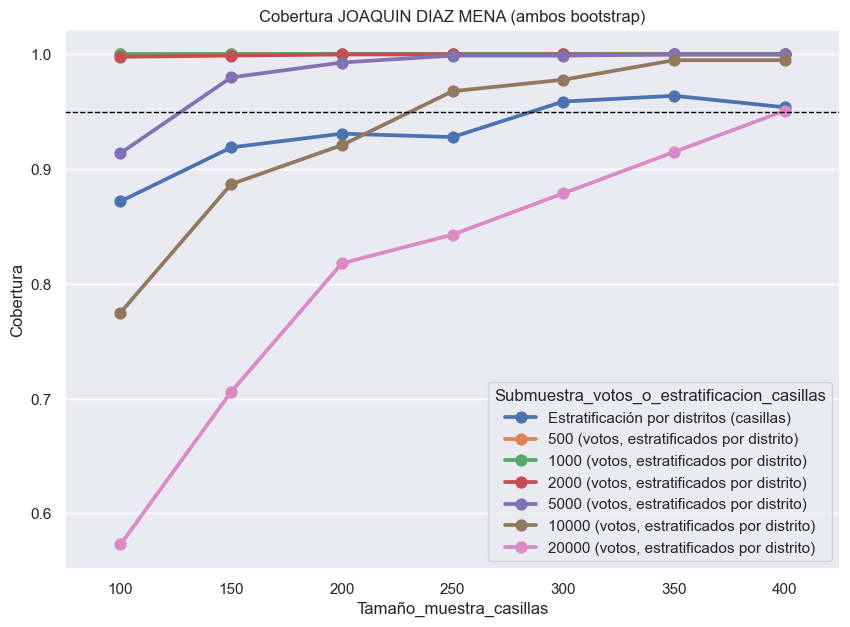

In [21]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Cob_JOAQUIN_DIAZ_MENA", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura JOAQUIN DIAZ MENA (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--')
ax.set(ylabel='Cobertura');

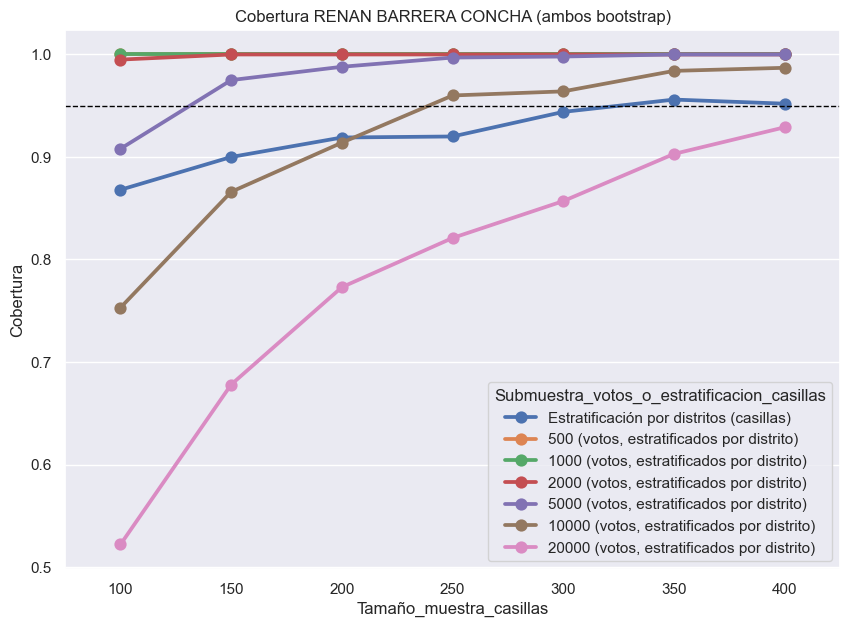

In [22]:
fig, ax = plt.subplots(figsize=(10,7))
sns.pointplot(ax=ax,data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Cob_RENAN_BARRERA_CONCHA", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura RENAN BARRERA CONCHA (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--')
ax.set(ylabel='Cobertura');

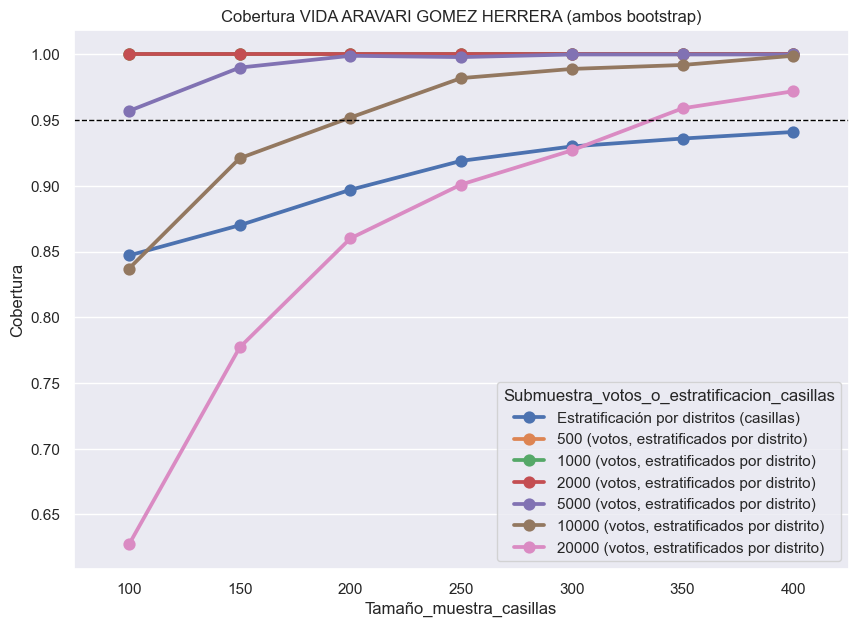

In [23]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Cob_VIDA_ARAVARI_GOMEZ_HERRERA", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura VIDA ARAVARI GOMEZ HERRERA (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--')
ax.set(ylabel='Cobertura');

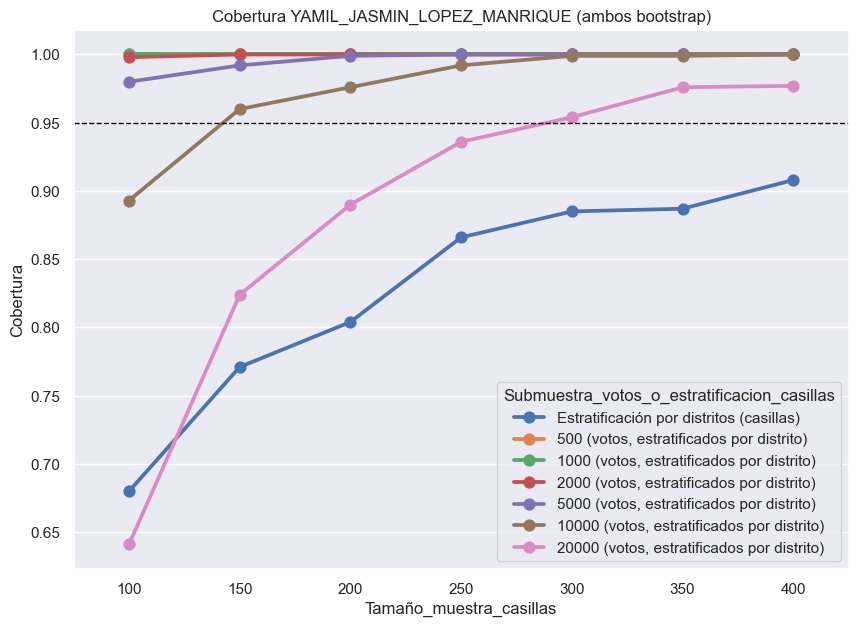

In [24]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura YAMIL_JASMIN_LOPEZ_MANRIQUE (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--')
ax.set(ylabel='Cobertura');

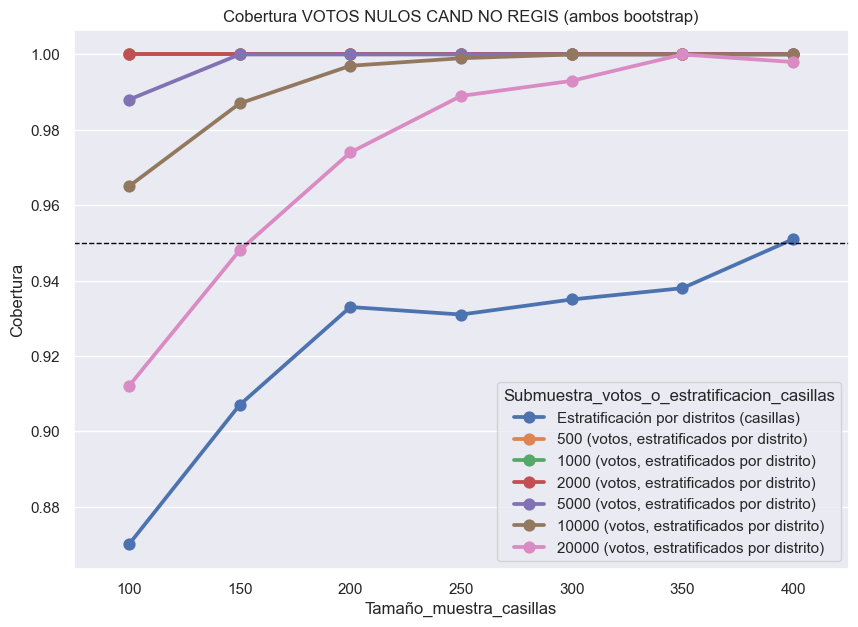

In [25]:
fig, ax = plt.subplots(figsize=(10,7))

sns.pointplot(ax=ax,data=df_bootraps_comb_2, x="Tamaño_muestra_casillas", y="Cob_VOTOS_NULOS_CAND_NO_REGIS", 
        hue="Submuestra_votos_o_estratificacion_casillas").set_title("Cobertura VOTOS NULOS CAND NO REGIS (ambos bootstrap)");
ax.axhline(y=0.95, linewidth=1, color='black', ls='--')
ax.set(ylabel='Cobertura');